In [30]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix



In [4]:
df = pd.read_csv('Fuel_station_theft_dataset.csv')
df

,station_id,transaction_date,station_type,region,fuel_type,litres_sold,transaction_value,payment_method,theft_flag,prevention_strategy,staff_present,incident_reported,resolution_status
0,ST1000,3/24/2014,Staffed,Christchurch,Diesel,75,214.26,Post-pay,0,ANPR,1,Yes,Pending
1,ST1001,3/29/2013,Unmanned,Christchurch,Diesel,61,186.59,Post-pay,0,Pre-pay Policy,1,No,Unresolved
2,ST1002,3/23/2015,Staffed,Auckland,95,25,71.90,Post-pay,0,CCTV,0,No,Recovered
3,ST1003,7/13/2015,Staffed,Wellington,95,61,178.66,Post-pay,0,ANPR,1,Yes,Recovered
4,ST1004,11/17/2016,Unmanned,Christchurch,91,33,94.27,Post-pay,0,NaN,1,Yes,Unresolved
...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,ST1303,2/16/2009,Unmanned,Dunedin,95,70,190.48,Pay-at-pump,0,NaN,0,No,Pending
304,ST1304,10/15/2009,Unmanned,Dunedin,95,40,123.12,Pay-at-pump,0,CCTV,0,No,Unresolved
305,ST1305,10/15/2009,Self-service,Hamilton,91,61,180.38,Pay-at-pump,0,CCTV,1,Yes,Unresolved
306,ST1306,2/16/2010,Unmanned,Dunedin,91,57,160.71,Pay-at-pump,0,NaN,0,No,Unresolved


In [11]:
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows in the dataset: {len(duplicate_rows)}")

Number of duplicate rows in the dataset: 0


In [5]:
print("\n--- Current Data Types ---")
print(df.dtypes)


--- Current Data Types ---
station_id                 str
transaction_date           str
station_type               str
region                     str
fuel_type                  str
litres_sold              int64
transaction_value      float64
payment_method             str
theft_flag               int64
prevention_strategy        str
staff_present            int64
incident_reported          str
resolution_status          str
dtype: object


In [6]:
date_column_name = 'transaction_date'
if date_column_name in df.columns:
    # Convert the column to datetime format
    df[date_column_name] = pd.to_datetime(df[date_column_name], errors='coerce')
    print(f"\nSuccessfully converted '{date_column_name}' to datetime type!")
    # Extract useful date features (Feature Engineering)
    df['year'] = df[date_column_name].dt.year
    df['month'] = df[date_column_name].dt.month
    df['day_of_week'] = df[date_column_name].dt.day_name()
else:
    print(f"\nNotice: Column '{date_column_name}' was not found.")


Successfully converted 'transaction_date' to datetime type!


In [11]:
# Check for missing values in each column and show only columns with missing data
missing_values = df.isnull().sum()

print("Number of missing values per column:")
print(missing_values[missing_values > 0])

# Check if there are any missing cells in the entire dataset (returns True or False)
print("\nAre there any missing cells in the entire dataset?:", df.isnull().any().any())

Number of missing values per column:
transaction_date       90
prevention_strategy    78
year                   90
month                  90
day_of_week            90
dtype: int64

Are there any missing cells in the entire dataset?: True


In [14]:
# 1. Handle missing values in date column using flexible parsing
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

# Fill missing dates using forward fill (or backward fill) to maintain chronological consistency
df['transaction_date'] = df['transaction_date'].ffill()
print("Missing values after ffill:", df['transaction_date'].isnull().sum())

# Re-extract date features after filling the missing dates
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.day_name()


# 2. Handle missing values for numerical columns (fill with median)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)


# 3. Handle missing values for categorical/text columns (fill with mode / most frequent value)
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)


# 4. Final verification: Check if any missing values remain
print("Remaining missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nAre there any missing cells left in the dataset?:", df.isnull().any().any())

Missing values after ffill: 0
Remaining missing values per column:
prevention_strategy    78
dtype: int64

Are there any missing cells left in the dataset?: True


C:\Users\moham\AppData\Local\Temp\ipykernel_42128\351702636.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns
C:\Users\moham\AppData\Local\Temp\ipykernel_42128\351702636.py:25: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doin

In [15]:
# Final validation of formats and data types
print("--- Final Column Data Types ---")
print(df.dtypes)

# Display a quick sample of the first 10 rows to visually check formatting
print("\n--- Sample of Cleaned Data ---")
display(df.head(10))

--- Final Column Data Types ---
station_id                        str
transaction_date       datetime64[us]
station_type                      str
region                            str
fuel_type                         str
litres_sold                     int64
transaction_value             float64
payment_method                    str
theft_flag                      int64
prevention_strategy               str
staff_present                   int64
incident_reported                 str
resolution_status                 str
year                            int32
month                           int32
day_of_week                       str
dtype: object

--- Sample of Cleaned Data ---


,station_id,transaction_date,station_type,region,fuel_type,litres_sold,transaction_value,payment_method,theft_flag,prevention_strategy,staff_present,incident_reported,resolution_status,year,month,day_of_week
0,ST1000,2014-03-24,Staffed,Christchurch,Diesel,75,214.26,Post-pay,0,ANPR,1,Yes,Pending,2014,3,Monday
1,ST1001,2013-03-29,Unmanned,Christchurch,Diesel,61,186.59,Post-pay,0,Pre-pay Policy,1,No,Unresolved,2013,3,Friday
2,ST1002,2015-03-23,Staffed,Auckland,95,25,71.90,Post-pay,0,CCTV,0,No,Recovered,2015,3,Monday
3,ST1003,2015-07-13,Staffed,Wellington,95,61,178.66,Post-pay,0,ANPR,1,Yes,Recovered,2015,7,Monday
4,ST1004,2016-11-17,Unmanned,Christchurch,91,33,94.27,Post-pay,0,NaN,1,Yes,Unresolved,2016,11,Thursday
5,ST1005,2017-07-17,Unmanned,Dunedin,91,41,114.56,Pre-pay,0,Pre-pay Policy,1,Yes,Pending,2017,7,Monday
6,ST1006,2017-07-17,Staffed,Wellington,91,46,127.97,Pre-pay,0,ANPR,0,No,Pending,2017,7,Monday
7,ST1007,2019-03-19,Self-service,Hamilton,Diesel,74,225.35,Pre-pay,0,NaN,1,Yes,Unresolved,2019,3,Tuesday
8,ST1008,2011-07-22,Staffed,Christchurch,95,75,208.38,Post-pay,0,CCTV,0,Yes,Pending,2011,7,Friday
9,ST1009,2011-11-22,Staffed,Christchurch,Diesel,38,105.91,Pay-at-pump,1,Pre-pay Policy,1,Yes,Recovered,2011,11,Tuesday


In [16]:
# Find the minimum (earliest) and maximum (latest) years in the transaction_date column
min_year = df['transaction_date'].dt.year.min()
max_year = df['transaction_date'].dt.year.max()

print(f"Earliest year: {min_year}")
print(f"Latest year: {max_year}")
print(f"Data range: From {min_year} to {max_year}")

Earliest year: 2005
Latest year: 2019
Data range: From 2005 to 2019


In [17]:
# Select a numerical column for segmentation and outlier analysis (e.g., 'litres_sold' or 'transaction_value')
target_col = 'litres_sold' 

# 1. Calculate Q1 (25th percentile), Q2 (Median/50th percentile), and Q3 (75th percentile)
q1 = df[target_col].quantile(0.25)
q2 = df[target_col].quantile(0.50)
q3 = df[target_col].quantile(0.75)

print(f"Q1 (25%): {q1}")
print(f"Q2 (Median/50%): {q2}")
print(f"Q3 (75%): {q3}")

# 2. Calculate Interquartile Range (IQR) and Outlier Bounds
iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

print(f"Lower Outlier Bound: {lower_bound}")
print(f"Upper Outlier Bound: {upper_bound}")

# 3. Identify and count outliers
outliers = df[(df[target_col] < lower_bound) | (df[target_col] > upper_bound)]
print(f"Number of outliers found: {len(outliers)}")

# 4. Perform Segmentation based on quartiles
# Defining segments: Low (<= Q1), Medium (Q1 to Q3), High (> Q3)
bins = [-float('inf'), q1, q3, float('inf')]
labels = ['Low', 'Medium', 'High']
df['segment'] = pd.cut(df[target_col], bins=bins, labels=labels)

print("\nSegment distribution:")
print(df['segment'].value_counts())

Q1 (25%): 34.0
Q2 (Median/50%): 46.0
Q3 (75%): 62.0
Lower Outlier Bound: -8.0
Upper Outlier Bound: 104.0
Number of outliers found: 0

Segment distribution:
segment
Medium    154
Low        81
High       73
Name: count, dtype: int64


In [18]:
# 1. Filter out the outliers to create a clean dataset for standard analysis
df_clean = df[~((df[target_col] < lower_bound) | (df[target_col] > upper_bound))]

# 2. Extract and group the outliers separately to analyze them (e.g., investigating severe fuel theft incidents)
outliers_df = df[(df[target_col] < lower_bound) | (df[target_col] > upper_bound)]

print(f"Total rows in clean dataset: {len(df_clean)}")
print(f"Total rows in outliers dataset: {len(outliers_df)}")

# 3. Group the outliers by categorical columns (e.g., station_type or region) to find theft patterns
outlier_grouped = outliers_df.groupby(['region', 'station_type']).agg(
    outlier_count=('station_id', 'count'),
    total_litres_lost=('litres_sold', 'sum'),
    avg_transaction_value=('transaction_value', 'mean')
).reset_index()

print("\n--- Outlier Grouping Analysis ---")
display(outlier_grouped)

Total rows in clean dataset: 308
Total rows in outliers dataset: 0

--- Outlier Grouping Analysis ---


,region,station_type,outlier_count,total_litres_lost,avg_transaction_value


In [19]:
# 1. Check unique values in categorical columns to spot spelling mistakes or inconsistencies
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"Unique values in '{col}':")
    print(df[col].unique())
    print("-" * 30)

# 2. Quick statistical summary to check for outliers or illogical values (like negative numbers)
print("\n--- Numerical Summary for Outliers Check ---")
print(df[['litres_sold', 'transaction_value']].describe())

Unique values in 'station_id':
<ArrowStringArray>
['ST1000', 'ST1001', 'ST1002', 'ST1003', 'ST1004', 'ST1005', 'ST1006',
 'ST1007', 'ST1008', 'ST1009',
 ...
 'ST1298', 'ST1299', 'ST1300', 'ST1301', 'ST1302', 'ST1303', 'ST1304',
 'ST1305', 'ST1306', 'ST1307']
Length: 308, dtype: str
------------------------------
Unique values in 'station_type':
<ArrowStringArray>
['Staffed', 'Unmanned', 'Self-service']
Length: 3, dtype: str
------------------------------
Unique values in 'region':
<ArrowStringArray>
['Christchurch', 'Auckland', 'Wellington', 'Dunedin', 'Hamilton']
Length: 5, dtype: str
------------------------------
Unique values in 'fuel_type':
<ArrowStringArray>
['Diesel', '95', '91']
Length: 3, dtype: str
------------------------------
Unique values in 'payment_method':
<ArrowStringArray>
['Post-pay', 'Pre-pay', 'Pay-at-pump']
Length: 3, dtype: str
------------------------------
Unique values in 'prevention_strategy':
<ArrowStringArray>
['ANPR', 'Pre-pay Policy', 'CCTV', nan]
Length

C:\Users\moham\AppData\Local\Temp\ipykernel_42128\4225609827.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [20]:
# 1. Standardize text columns (strip extra spaces and standardize casing)
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

# 2. Check for logical errors (negative or zero values in sales/values)
print("Checking for illogical negative values:")
print(f"Negative litres_sold count: {(df['litres_sold'] < 0).sum()}")
print(f"Negative transaction_value count: {(df['transaction_value'] < 0).sum()}")

# 3. Verify unique values in binary or flag columns to ensure no unexpected entries
print("\nUnique values in flag and status columns:")
print("theft_flag unique values:", df['theft_flag'].unique())
print("staff_present unique values:", df['staff_present'].unique())
print("incident_reported unique values:", df['incident_reported'].unique())

Checking for illogical negative values:
Negative litres_sold count: 0
Negative transaction_value count: 0

Unique values in flag and status columns:
theft_flag unique values: [0 1]
staff_present unique values: [1 0]
incident_reported unique values: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str


C:\Users\moham\AppData\Local\Temp\ipykernel_42128\3950413452.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [21]:
# 1. Descriptive Statistics for Numerical Columns
print("--- Descriptive Statistics ---")
print(df.describe())

# 2. Groupby Statistics (Analyzing theft flags and sales by station type and region)
print("\n--- Summary by Station Type and Region ---")
station_summary = df.groupby(['station_type', 'region']).agg(
    total_sales=('litres_sold', 'sum'),
    avg_transaction=('transaction_value', 'mean'),
    total_thefts=('theft_flag', 'sum')
).reset_index()
display(station_summary)

# 3. Correlation Matrix for Numerical Features
print("\n--- Correlation Matrix ---")
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[num_cols].corr()
display(correlation_matrix)

--- Descriptive Statistics ---
                 transaction_date  litres_sold  transaction_value  theft_flag  \
count                         308   308.000000         308.000000  308.000000   
mean   2012-07-14 00:56:06.233766    48.246753         140.490617    0.110390   
min           2005-10-17 00:00:00    20.000000          56.620000    0.000000   
25%           2009-01-27 00:00:00    34.000000          97.937500    0.000000   
50%           2012-11-26 00:00:00    46.000000         132.785000    0.000000   
75%           2015-04-15 00:00:00    62.000000         182.925000    0.000000   
max           2019-08-16 00:00:00    79.000000         243.720000    1.000000   
std                           NaN    17.199088          51.240268    0.313885   

       staff_present         year       month  
count     308.000000   308.000000  308.000000  
mean        0.373377  2012.058442    6.103896  
min         0.000000  2005.000000    1.000000  
25%         0.000000  2009.000000    3.000000  

,station_type,region,total_sales,avg_transaction,total_thefts
0,Self-Service,Auckland,985,150.408421,1
1,Self-Service,Christchurch,713,138.503333,2
2,Self-Service,Dunedin,1001,116.454000,4
3,Self-Service,Hamilton,939,151.387778,2
4,Self-Service,Wellington,765,123.953889,1
5,Staffed,Auckland,1193,138.427200,2
6,Staffed,Christchurch,1014,146.310000,3
7,Staffed,Dunedin,1215,158.053913,4
8,Staffed,Hamilton,901,146.365556,4
9,Staffed,Wellington,1145,143.656522,2



--- Correlation Matrix ---


,litres_sold,transaction_value,theft_flag,staff_present
litres_sold,1.000000,0.993606,-0.049108,-0.091619
transaction_value,0.993606,1.000000,-0.048507,-0.083220
theft_flag,-0.049108,-0.048507,1.000000,0.027957
staff_present,-0.091619,-0.083220,0.027957,1.000000


Chi-2 Statistic: 7.1854
p-value: 0.1264
Result: No significant relationship found between Region and Theft (Fail to reject H0).


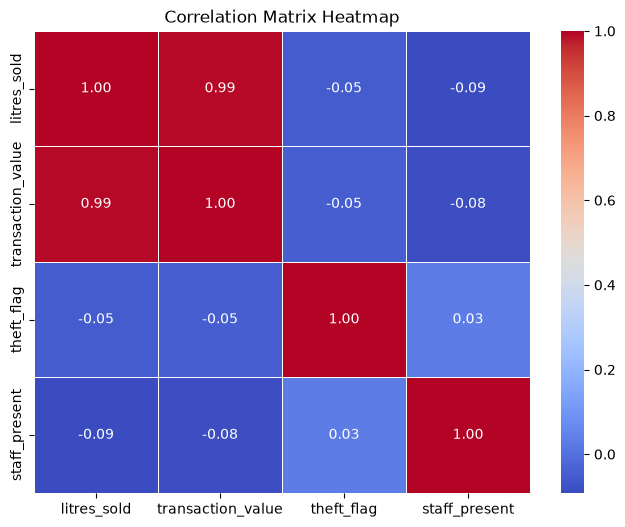

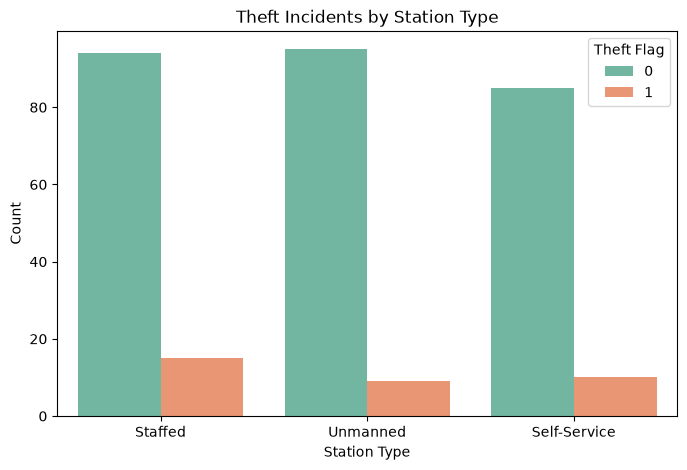

In [22]:
# --- 1. Chi-Square Test for Independence ---
# Testing if there is a significant relationship between 'region' and 'theft_flag'
contingency_table = pd.crosstab(df['region'], df['theft_flag'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-2 Statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Significant relationship found between Region and Theft (Reject H0).")
else:
    print("Result: No significant relationship found between Region and Theft (Fail to reject H0).")


# --- 2. Visualizations ---

# Correlation Heatmap
plt.figure(figsize=(8, 6))
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

# Theft Count by Station Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='station_type', hue='theft_flag', palette='Set2')
plt.title('Theft Incidents by Station Type')
plt.xlabel('Station Type')
plt.ylabel('Count')
plt.legend(title='Theft Flag')
plt.show()

C:\Users\moham\AppData\Local\Temp\ipykernel_42128\523642687.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='theft_flag', y='litres_sold', palette='Set3')


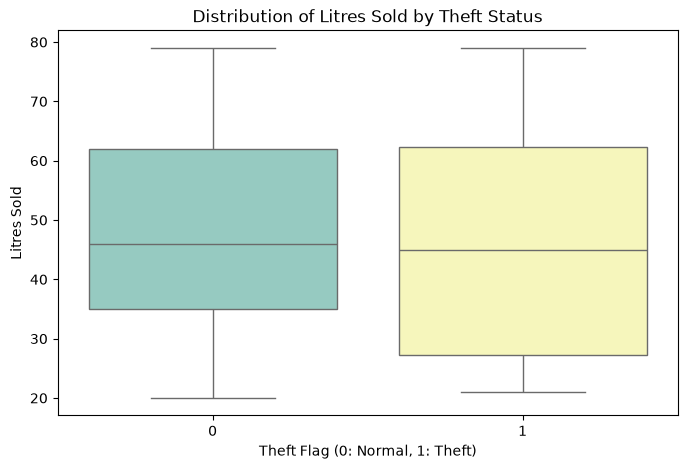


--- Average Transaction Value by Region & Theft ---


theft_flag,0,1
region,,
Auckland,145.984310,103.000000
Christchurch,141.082449,145.414286
Dunedin,137.369167,117.372000
Hamilton,145.991489,159.742000
Wellington,137.501000,112.043333


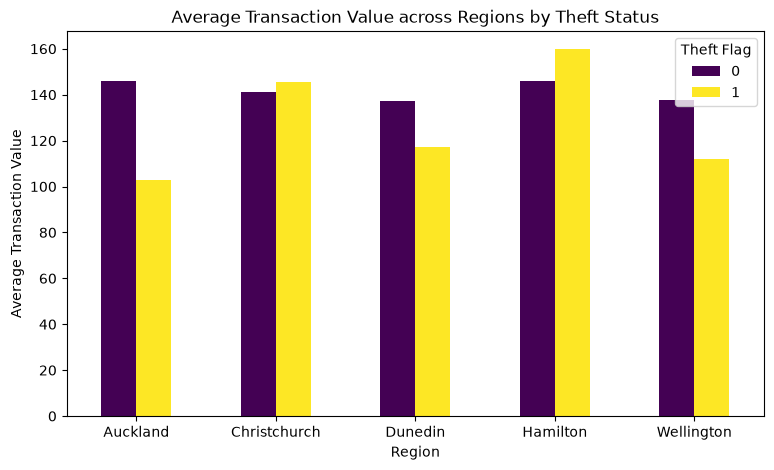

In [24]:
# 1. Boxplot: Comparing Litres Sold distribution by Theft Flag
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='theft_flag', y='litres_sold', palette='Set3')
plt.title('Distribution of Litres Sold by Theft Status')
plt.xlabel('Theft Flag (0: Normal, 1: Theft)')
plt.ylabel('Litres Sold')
plt.show()

# 2. Average Transaction Value grouped by Region and Theft Flag
region_theft_summary = df.groupby(['region', 'theft_flag'])['transaction_value'].mean().unstack()
print("\n--- Average Transaction Value by Region & Theft ---")
display(region_theft_summary)

# 3. Bar Plot for Region vs Average Transaction Value
region_theft_summary.plot(kind='bar', figsize=(9, 5), colormap='viridis')
plt.title('Average Transaction Value across Regions by Theft Status')
plt.xlabel('Region')
plt.ylabel('Average Transaction Value')
plt.xticks(rotation=0)
plt.legend(title='Theft Flag')
plt.show()

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        55
           1       0.00      0.00      0.00         7

    accuracy                           0.85        62
   macro avg       0.44      0.48      0.46        62
weighted avg       0.78      0.85      0.82        62



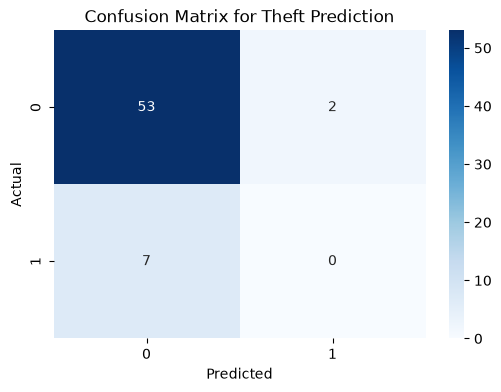

In [26]:
# 1. Define Features (X) and Target (y)
features = ['litres_sold', 'transaction_value']
X = df[features]
y = df['theft_flag']

# 2. Split Data into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize and Train Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# 4. Predict on Test Set
y_pred = rf_model.predict(X_test)

# 5. Evaluate the Model
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Theft Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

--- Feature Importance ---


,Feature,Importance
1,transaction_value,0.66495
0,litres_sold,0.33505


C:\Users\moham\AppData\Local\Temp\ipykernel_42128\2275972370.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')


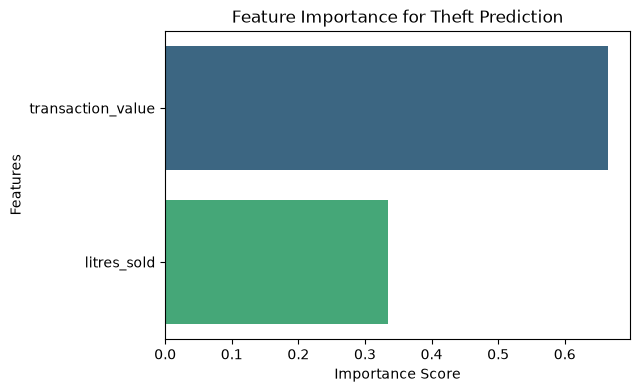


Project Saved Successfully!
- Cleaned dataset saved as: 'cleaned_fuel_data.csv'
- Trained ML model saved as: 'fuel_theft_model.pkl'


In [28]:
# 1. Feature Importance Analysis (Which feature contributed most to the model)
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("--- Feature Importance ---")
display(feature_importance_df)

# Plot Feature Importance
plt.figure(figsize=(6, 4))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance for Theft Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# 2. Save the Cleaned Dataset and Trained Model
df.to_csv('cleaned_fuel_data.csv', index=False)
joblib.dump(rf_model, 'fuel_theft_model.pkl')

print("\nProject Saved Successfully!")
print("- Cleaned dataset saved as: 'cleaned_fuel_data.csv'")
print("- Trained ML model saved as: 'fuel_theft_model.pkl'")

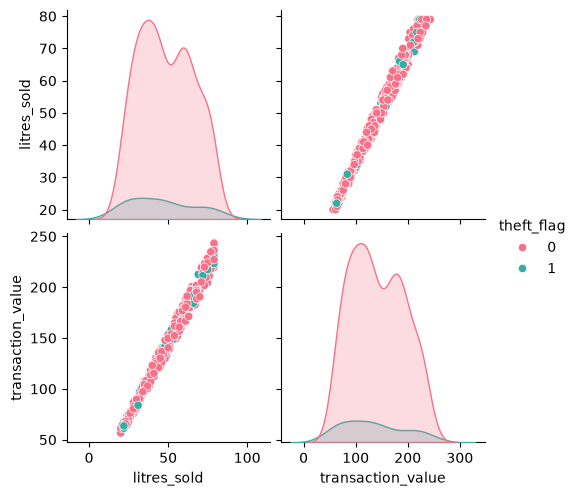


--- Multi-Level Grouping: Station Type & Region vs Litres Sold ---


,station_type,region,mean,median,std,count
0,Self-Service,Auckland,51.842105,46.0,18.792029,19
1,Self-Service,Christchurch,47.533333,39.0,17.614388,15
2,Self-Service,Dunedin,40.040000,37.0,16.172198,25
3,Self-Service,Hamilton,52.166667,58.0,16.252602,18
4,Self-Service,Wellington,42.500000,42.0,19.315492,18
5,Staffed,Auckland,47.720000,46.0,16.333810,25
6,Staffed,Christchurch,50.700000,45.5,19.558549,20
7,Staffed,Dunedin,52.826087,48.0,17.882577,23
8,Staffed,Hamilton,50.055556,48.5,19.095648,18
9,Staffed,Wellington,49.782609,51.0,14.752370,23



--- Pivot Table: Total Thefts by Region and Station Type ---


station_type,Self-Service,Staffed,Unmanned
region,,,
Auckland,1,2,1
Christchurch,2,3,2
Dunedin,4,4,2
Hamilton,2,4,4
Wellington,1,2,0


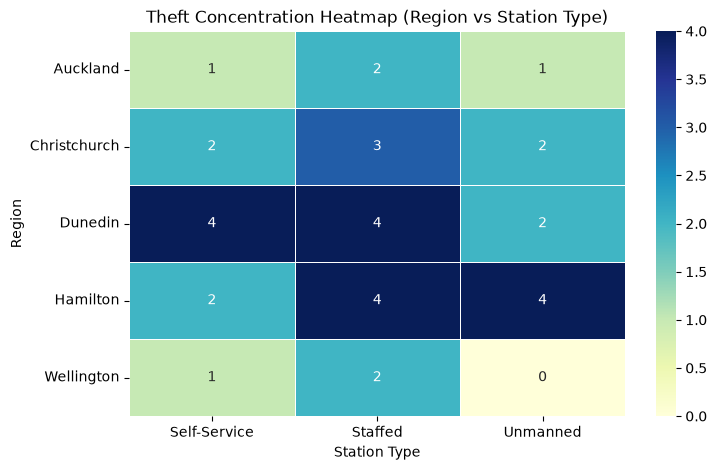

In [29]:
# 1. Pairplot: Exploring pairwise relationships and distributions across data segments
sns.pairplot(df[['litres_sold', 'transaction_value', 'station_type', 'theft_flag']], hue='theft_flag', palette='husl')
plt.show()

# 2. Advanced Groupby: Interaction between Station Type, Region, and Average Litres Sold
multi_group = df.groupby(['station_type', 'region'])['litres_sold'].agg(['mean', 'median', 'std', 'count']).reset_index()
print("\n--- Multi-Level Grouping: Station Type & Region vs Litres Sold ---")
display(multi_group)

# 3. Pivot Table: To see the exact interaction and impact between Region and Station Type on Theft Count
pivot_theft = df.pivot_table(values='theft_flag', index='region', columns='station_type', aggfunc='sum')
print("\n--- Pivot Table: Total Thefts by Region and Station Type ---")
display(pivot_theft)

# Heatmap for the Pivot Table to visualize the cross-impact clearly
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_theft, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5)
plt.title('Theft Concentration Heatmap (Region vs Station Type)')
plt.xlabel('Station Type')
plt.ylabel('Region')
plt.show()

<Figure size 800x600 with 0 Axes>

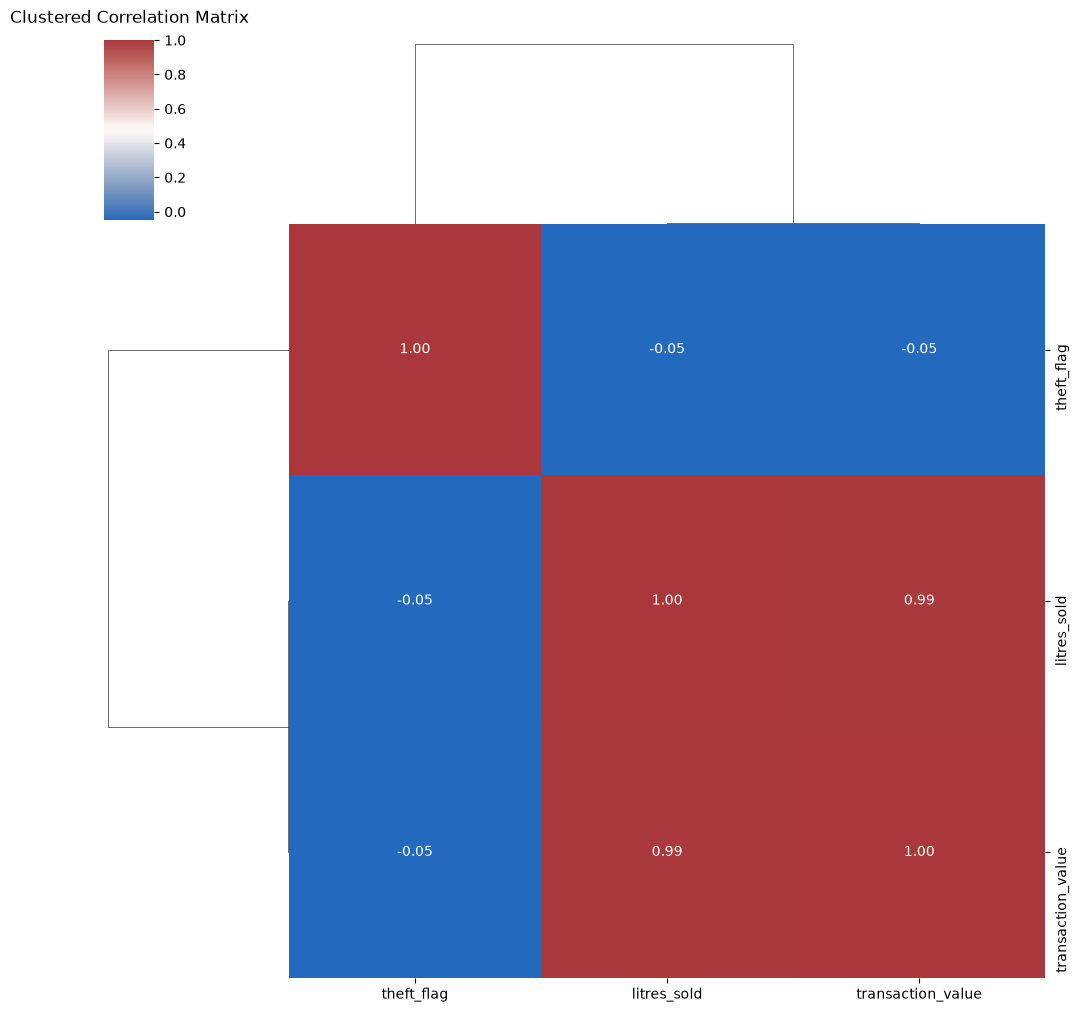

<Figure size 900x500 with 0 Axes>

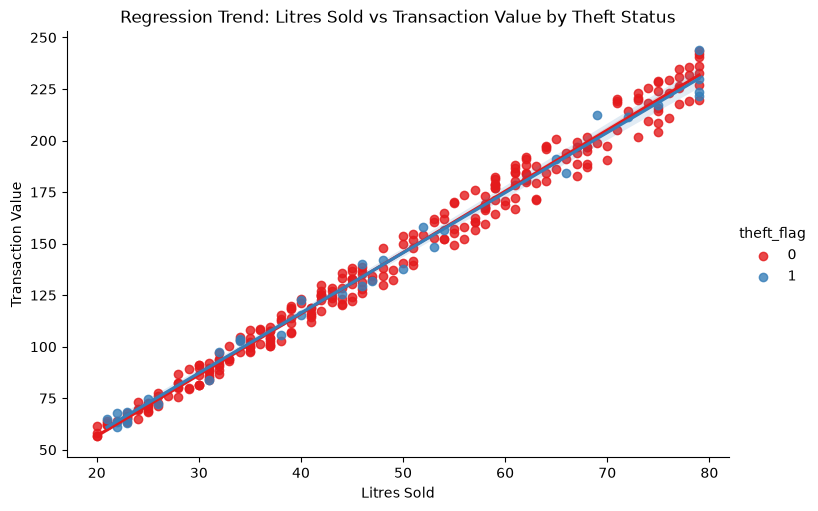


--- Logistic Regression Impact Coefficients ---


,Feature,Coefficient
1,transaction_value,-0.074673
0,litres_sold,-0.081383


In [31]:
# 1. Clustered Heatmap to group similar regions and metrics based on correlations
plt.figure(figsize=(8, 6))
sns.clustermap(df[['litres_sold', 'transaction_value', 'theft_flag']].corr(), cmap='vlag', annot=True, fmt='.2f')
plt.title('Clustered Correlation Matrix', y=1.05)
plt.show()

# 2. Regression Scatter Plot: Relationship between Litres Sold and Transaction Value colored by Theft
plt.figure(figsize=(9, 5))
sns.lmplot(data=df, x='litres_sold', y='transaction_value', hue='theft_flag', palette='Set1', aspect=1.5, height=5)
plt.title('Regression Trend: Litres Sold vs Transaction Value by Theft Status')
plt.xlabel('Litres Sold')
plt.ylabel('Transaction Value')
plt.show()


# Scale features for fair coefficient comparison
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

log_model = LogisticRegression(random_state=42)
log_model.fit(X_scaled, y)

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\n--- Logistic Regression Impact Coefficients ---")
display(coef_df)

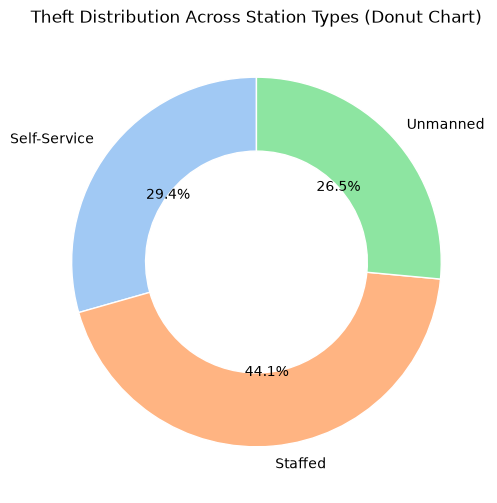

In [32]:
# Donut Chart: Proportion of Theft Incidents by Station Type
station_theft = df.groupby('station_type')['theft_flag'].sum()

plt.figure(figsize=(6, 6))
plt.pie(
    station_theft, 
    labels=station_theft.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=sns.color_palette('pastel'), 
    wedgeprops=dict(width=0.4, edgecolor='white')
)
plt.title('Theft Distribution Across Station Types (Donut Chart)')
plt.show()

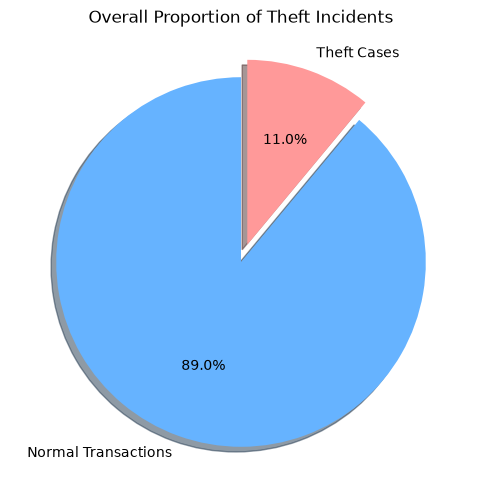

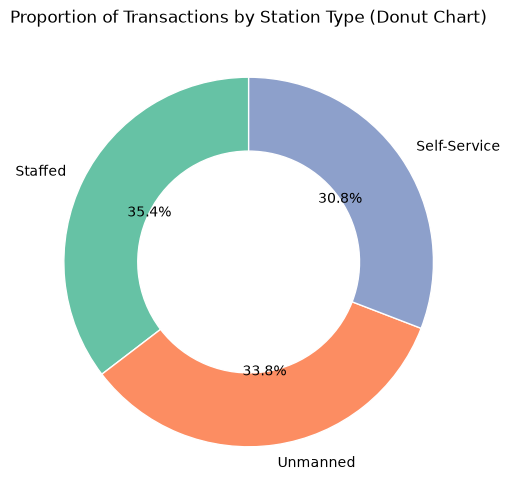

In [33]:
# 1. Pie Chart: Overall Theft Status Distribution (0 vs 1)
theft_counts = df['theft_flag'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    theft_counts, 
    labels=['Normal Transactions', 'Theft Cases'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#66b3ff', '#ff9999'], 
    explode=(0, 0.1),
    shadow=True
)
plt.title('Overall Proportion of Theft Incidents')
plt.show()

# 2. Donut Chart: Proportion of Station Types
station_counts = df['station_type'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    station_counts, 
    labels=station_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=sns.color_palette('Set2'), 
    wedgeprops=dict(width=0.4, edgecolor='white') 
)
plt.title('Proportion of Transactions by Station Type (Donut Chart)')
plt.show()

In [41]:

# Automatically find any column related to date, time, or day
potential_date_cols = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower() or 'day' in col.lower()]

if potential_date_cols:
    date_col = potential_date_cols[0]
    print(f"Automatically detected date column: {date_col}")
    
    df[date_col] = pd.to_datetime(df[date_col])
    df['day_of_week'] = df[date_col].dt.day_name()
    df.to_csv('cleaned_fuel_data.csv', index=False)
    print("Day of the week column successfully created and file saved!")
else:
    print("Could not auto-detect a date column. Here are your actual column names:", df.columns.tolist())

Automatically detected date column: transaction_date
Day of the week column successfully created and file saved!


In [50]:
# Force-replace the numeric codes with descriptive text labels
df['fuel_type'] = df['fuel_type'].replace({
    91: 'Gasoline 91',
    95: 'Gasoline 95',
    '91': 'Gasoline 91',
    '95': 'Gasoline 95'
})

# Ensure the entire column is treated as string text
df['fuel_type'] = df['fuel_type'].astype(str)

# Save the updated file
df.to_csv('cleaned_fuel_data.csv', index=False)
print("Fuel types successfully updated to text and file saved!")

Fuel types successfully updated to text and file saved!
